<a href="https://colab.research.google.com/github/semmatoninn/CHE1148_MOFs_AtomicWizards/blob/main/Configuration_level_EGNN_FullStructure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1) INSTALL
%%capture
# Check runtime first: Runtime -> Change runtime type -> GPU
!nvidia-smi

import os
import sys
import subprocess

# Install PyG wheels matched to current Colab torch/cuda
import torch
print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)

TORCH = torch.__version__.split("+")[0]
CUDA = "cpu" if torch.version.cuda is None else "cu" + torch.version.cuda.replace(".", "")

# Official PyG wheel index pattern

!pip install --progress-bar off pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html

!pip -qq install torch_geometric
!pip -qq install scipy pandas scikit-learn tqdm

print("Install done.")

In [2]:
# 2) MOUNT DRIVE + IMPORTS

from google.colab import drive
drive.mount('/content/drive')

import math
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool, radius_graph
from torch_geometric.utils import remove_self_loops

from scipy.stats import spearmanr, kendalltau
from sklearn.metrics import mean_absolute_error, mean_squared_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [3]:
# 3) PATHS + CONFIG

BASE_DIR = Path("/content/drive/MyDrive/MOF_Conf/processed_pyg")

TRAIN_DIR = BASE_DIR / "train"
VAL_DIR   = BASE_DIR / "val"
TEST_DIR  = BASE_DIR / "test"

print(TRAIN_DIR)
print(VAL_DIR)
print(TEST_DIR)

# Training / graph settings
SEED = 42
BATCH_SIZE = 4          # safe starting point for ~300-atom graphs on T4
NUM_WORKERS = 2
LR = 3e-4
WEIGHT_DECAY = 1e-5
MAX_EPOCHS = 100
PATIENCE = 15

# Graph construction
CUTOFF = 4.0            # Angstrom, reasonable starting value
MAX_NEIGHBORS = 24      # helps memory / stability

# Model size
EMBED_DIM = 160
HIDDEN_DIM = 160
NUM_LAYERS = 5
DROPOUT = 0.1

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

/content/drive/MyDrive/MOF_Conf/processed_pyg/train
/content/drive/MyDrive/MOF_Conf/processed_pyg/val
/content/drive/MyDrive/MOF_Conf/processed_pyg/test


In [4]:
# 4) LOAD CHUNKED DATA FROM DRIVE

def sorted_pt_files(folder: Path):
    return sorted(folder.glob("*.pt"))

train_files = sorted_pt_files(TRAIN_DIR)
val_files   = sorted_pt_files(VAL_DIR)
test_files  = sorted_pt_files(TEST_DIR)

print("Train files:", [f.name for f in train_files])
print("Val files:", [f.name for f in val_files])
print("Test files:", [f.name for f in test_files])

def load_chunk_list(pt_files):
    data_list = []
    for f in pt_files:
        print(f"Loading {f.name} ...")
        chunk = torch.load(f, map_location="cpu", weights_only=False)
        if isinstance(chunk, list):
            data_list.extend(chunk)
        else:
            raise TypeError(f"Unexpected object in {f}: {type(chunk)}")
    return data_list

train_data = load_chunk_list(train_files)
val_data   = load_chunk_list(val_files)
test_data  = load_chunk_list(test_files)

print(f"Train samples: {len(train_data)}")
print(f"Val samples:   {len(val_data)}")
print(f"Test samples:  {len(test_data)}")

sample = train_data[0]
print(sample)
print("Keys:", sample.keys())
print("z shape:", sample.z.shape)
print("pos shape:", sample.pos.shape)
print("y:", sample.y)
print("mof_name:", sample.mof_name)
print("config_name:", sample.config_name)

Train files: ['train_part_000.pt', 'train_part_001.pt', 'train_part_002.pt', 'train_part_003.pt']
Val files: ['val_part_000.pt']
Test files: ['test_part_000.pt']
Loading train_part_000.pt ...
Loading train_part_001.pt ...
Loading train_part_002.pt ...
Loading train_part_003.pt ...
Loading val_part_000.pt ...
Loading test_part_000.pt ...
Train samples: 1860
Val samples:   427
Test samples:  444
Data(y=[1], pos=[277, 3], z=[277], cell=[3, 3], pbc=[3], mof_name='ADOBEB_charged', config_name='ADOBEB_charged_w_CO2_1', num_atoms=277, split='train')
Keys: ['pos', 'z', 'config_name', 'y', 'cell', 'pbc', 'split', 'mof_name', 'num_atoms']
z shape: torch.Size([277])
pos shape: torch.Size([277, 3])
y: tensor([-0.1344])
mof_name: ADOBEB_charged
config_name: ADOBEB_charged_w_CO2_1


In [5]:
# inspect keys more carefully
for k in train_data[0].keys():
    print(k, type(getattr(train_data[0], k)))

pos <class 'torch.Tensor'>
z <class 'torch.Tensor'>
config_name <class 'str'>
y <class 'torch.Tensor'>
cell <class 'torch.Tensor'>
pbc <class 'torch.Tensor'>
split <class 'str'>
mof_name <class 'str'>
num_atoms <class 'int'>


In [6]:
print(train_data[0])
print(train_data[0].to_dict().keys() if hasattr(train_data[0], "to_dict") else "no to_dict")

Data(y=[1], pos=[277, 3], z=[277], cell=[3, 3], pbc=[3], mof_name='ADOBEB_charged', config_name='ADOBEB_charged_w_CO2_1', num_atoms=277, split='train')
dict_keys(['y', 'pos', 'z', 'cell', 'pbc', 'mof_name', 'config_name', 'num_atoms', 'split'])


In [7]:
# 5) PRECOMPUTE EDGE_INDEX

def ensure_tensor_y(data):
    # make sure y is float tensor of shape [1]
    if not torch.is_tensor(data.y):
        data.y = torch.tensor([float(data.y)], dtype=torch.float)
    else:
        data.y = data.y.view(-1).float()
        if data.y.numel() == 1:
            pass
        else:
            data.y = data.y[:1]
    return data

def add_radius_edges(data, cutoff=CUTOFF, max_neighbors=MAX_NEIGHBORS):
    data = ensure_tensor_y(data)

    if hasattr(data, "edge_index") and data.edge_index is not None:
        return data

    pos = data.pos.float()
    edge_index = radius_graph(
        x=pos,
        r=cutoff,
        loop=False,
        max_num_neighbors=max_neighbors
    )
    edge_index, _ = remove_self_loops(edge_index)
    data.edge_index = edge_index
    return data

def preprocess_dataset(data_list, cutoff=CUTOFF, max_neighbors=MAX_NEIGHBORS):
    processed = []
    for data in tqdm(data_list):
        d = add_radius_edges(data, cutoff=cutoff, max_neighbors=max_neighbors)
        processed.append(d)
    return processed

train_data = preprocess_dataset(train_data)
val_data   = preprocess_dataset(val_data)
test_data  = preprocess_dataset(test_data)

# inspect one sample
s = train_data[0]
print("edge_index shape:", s.edge_index.shape)
print("num_nodes:", s.num_nodes)
print("num_edges:", s.edge_index.shape[1])

  0%|          | 0/1860 [00:00<?, ?it/s]

  0%|          | 0/427 [00:00<?, ?it/s]

  0%|          | 0/444 [00:00<?, ?it/s]

edge_index shape: torch.Size([2, 3726])
num_nodes: 277
num_edges: 3726


In [8]:
# 6) DATALOADERS

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

batch = next(iter(train_loader))
print(batch)
print("Batch num graphs:", batch.num_graphs)
print("Batch x nodes:", batch.z.shape)
print("Batch pos:", batch.pos.shape)
print("Batch y:", batch.y.shape)

DataBatch(y=[4], pos=[882, 3], z=[882], cell=[12, 3], pbc=[12], mof_name=[4], config_name=[4], num_atoms=[4], split=[4], edge_index=[2, 12053], batch=[882], ptr=[5])
Batch num graphs: 4
Batch x nodes: torch.Size([882])
Batch pos: torch.Size([882, 3])
Batch y: torch.Size([4])


In [9]:
# 7) MODEL - EGNN

# =========================
# 7) MODEL
# =========================

class StableEGNNLayer(MessagePassing):
    def __init__(self, hidden_dim, dropout=0.0):
        super().__init__(aggr='add')
        self.hidden_dim = hidden_dim

        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU()
        )

        self.node_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, h, pos, edge_index):
        row, col = edge_index

        rel = pos[row] - pos[col]
        dist2 = (rel ** 2).sum(dim=-1, keepdim=True)
        dist = torch.sqrt(dist2 + 1e-8)
        dist = torch.clamp(dist / CUTOFF, min=0.0, max=10.0)

        m_ij = self.edge_mlp(torch.cat([h[row], h[col], dist], dim=-1))
        m_ij = self.dropout(m_ij)

        agg = torch.zeros_like(h)
        agg.index_add_(0, row, m_ij)

        h_update = self.node_mlp(torch.cat([h, agg], dim=-1))
        h = self.norm(h + h_update)

        return h


class EnergyEGNN(nn.Module):
    def __init__(
        self,
        num_atom_types=120,
        embed_dim=64,
        hidden_dim=160,
        num_layers=5,
        dropout=0.1
    ):
        super().__init__()

        self.embedding = nn.Embedding(num_atom_types, embed_dim)
        self.input_proj = nn.Linear(embed_dim, hidden_dim)

        self.layers = nn.ModuleList([
            StableEGNNLayer(hidden_dim=hidden_dim, dropout=dropout)
            for _ in range(num_layers)
        ])

        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.SiLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        z = data.z.long()
        pos = data.pos.float()
        edge_index = data.edge_index
        batch = data.batch

        h = self.embedding(z)
        h = self.input_proj(h)

        for layer in self.layers:
            h = layer(h, pos, edge_index)

        g = global_mean_pool(h, batch)
        out = self.readout(g).view(-1)
        return out

In [12]:
# 8) INIT TRAINING OBJECTS


LR = 3e-4
WEIGHT_DECAY = 1e-5
model = EnergyEGNN(
    num_atom_types=120,
    embed_dim=64,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.7,
    patience=5
)

loss_fn = nn.MSELoss()

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {num_params:,}")

Trainable params: 830,401


In [13]:

# 9) METRICS

import math
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, kendalltau

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def compute_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    metrics = {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "Spearman": spearmanr(y_true, y_pred).correlation,
        "Kendall": kendalltau(y_true, y_pred).correlation,
        "n_samples": len(y_true),
    }
    return metrics

In [14]:
# 10) TRAIN + EVAL HELPERS (CONFIG)

import numpy as np
from tqdm.auto import tqdm
import torch

# =========================
# 10) TRAIN + EVAL HELPERS
# =========================

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    n_graphs = 0
    bad_batches = 0

    for batch in tqdm(loader, leave=False):
        batch = batch.to(device)

        optimizer.zero_grad()
        pred = model(batch)
        target = batch.y.view(-1).float()

        if torch.isnan(pred).any() or torch.isinf(pred).any():
            bad_batches += 1
            continue

        if torch.isnan(target).any() or torch.isinf(target).any():
            bad_batches += 1
            continue

        loss = loss_fn(pred, target)

        if torch.isnan(loss) or torch.isinf(loss):
            bad_batches += 1
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
        optimizer.step()

        bs = batch.num_graphs
        running_loss += loss.item() * bs
        n_graphs += bs

    print(f"Bad train batches skipped: {bad_batches}")
    return running_loss / max(n_graphs, 1)


@torch.no_grad()
def predict_records(model, loader, device):
    model.eval()
    records = []
    skipped = 0

    for batch in tqdm(loader, leave=False):
        batch = batch.to(device)
        pred = model(batch)
        true = batch.y.view(-1)

        pred = pred.detach().cpu()
        true = true.detach().cpu()

        mof_names = batch.mof_name if hasattr(batch, "mof_name") else [None] * len(pred)
        config_names = batch.config_name if hasattr(batch, "config_name") else [None] * len(pred)

        for i in range(len(pred)):
            yp = float(pred[i])
            yt = float(true[i])

            if np.isnan(yp) or np.isinf(yp) or np.isnan(yt) or np.isinf(yt):
                skipped += 1
                continue

            records.append({
                "mof_name": mof_names[i],
                "config_name": config_names[i],
                "y_true": yt,
                "y_pred": yp,
            })

    print(f"Skipped invalid prediction records: {skipped}")
    return records


def evaluate_loader(model, loader, device):
    records = predict_records(model, loader, device)

    if len(records) == 0:
        raise ValueError("No valid prediction records found; model outputs are all NaN/Inf.")

    y_true = [r["y_true"] for r in records]
    y_pred = [r["y_pred"] for r in records]

    metrics = compute_regression_metrics(y_true, y_pred)

    return {
        "records": records,
        "metrics": metrics,
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
    }

In [15]:
# 11) EARLY STOPPING

class EarlyStopping:
    def __init__(self, patience=15, mode="min"):
        self.patience = patience
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, score, model):
        improved = False

        if self.best_score is None:
            improved = True
        elif self.mode == "min" and score < self.best_score:
            improved = True
        elif self.mode == "max" and score > self.best_score:
            improved = True

        if improved:
            self.best_score = score
            self.counter = 0
            self.best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

In [16]:
# 12) TRAINING LOOP

history = []
early_stopper = EarlyStopping(patience=PATIENCE, mode="min")

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)

    val_out = evaluate_loader(model, val_loader, device)
    val_metrics = val_out["metrics"]

    monitor = val_metrics["RMSE"]
    scheduler.step(monitor)
    early_stopper.step(monitor, model)

    lr_now = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_RMSE": val_metrics["RMSE"],
        "val_MAE": val_metrics["MAE"],
        "val_Spearman": val_metrics["Spearman"],
        "val_Kendall": val_metrics["Kendall"],
        "lr": lr_now,
    }
    history.append(row)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.5f} | "
        f"val_RMSE={val_metrics['RMSE']:.5f} | "
        f"val_MAE={val_metrics['MAE']:.5f} | "
        f"val_S={val_metrics['Spearman']:.4f} | "
        f"val_K={val_metrics['Kendall']:.4f} | "
        f"lr={lr_now:.2e}"
    )

    if early_stopper.should_stop:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

if early_stopper.best_state is not None:
    model.load_state_dict(early_stopper.best_state)
    print("Loaded best validation checkpoint.")

  0%|          | 0/465 [00:00<?, ?it/s]

Bad train batches skipped: 0


  0%|          | 0/107 [00:00<?, ?it/s]

Skipped invalid prediction records: 0
Epoch 001 | train_loss=0.25851 | val_RMSE=0.59963 | val_MAE=0.39937 | val_S=0.1369 | val_K=0.0931 | lr=3.00e-04


  0%|          | 0/465 [00:00<?, ?it/s]

...

Skipped invalid prediction records: 0
Epoch 025 | train_loss=0.24566 | val_RMSE=0.59810 | val_MAE=0.39875 | val_S=0.1589 | val_K=0.1032 | lr=1.03e-04


  0%|          | 0/465 [00:00<?, ?it/s]

Bad train batches skipped: 0


  0%|          | 0/107 [00:00<?, ?it/s]

Skipped invalid prediction records: 0
Epoch 026 | train_loss=0.24489 | val_RMSE=0.59639 | val_MAE=0.39330 | val_S=0.2039 | val_K=0.1358 | lr=1.03e-04
Early stopping triggered at epoch 26.
Loaded best validation checkpoint.


In [17]:
# =========================
# 13) FINAL VALIDATION + TEST
# =========================

val_final = evaluate_loader(model, val_loader, device)
test_final = evaluate_loader(model, test_loader, device)

print("\n=== VALIDATION (CONFIG-LEVEL) ===")
for k, v in val_final["metrics"].items():
    print(f"{k}: {v}")

print("\n=== TEST (CONFIG-LEVEL) ===")
for k, v in test_final["metrics"].items():
    print(f"{k}: {v}")

  0%|          | 0/107 [00:00<?, ?it/s]

Skipped invalid prediction records: 0


  0%|          | 0/111 [00:00<?, ?it/s]

Skipped invalid prediction records: 0

=== VALIDATION (CONFIG-LEVEL) ===
RMSE: 0.5722440005671536
MAE: 0.38964064956797545
Spearman: 0.2600858043960796
Kendall: 0.17756911726976812
n_samples: 427

=== TEST (CONFIG-LEVEL) ===
RMSE: 0.5210168129482639
MAE: 0.40012687629497035
Spearman: 0.2352019709363661
Kendall: 0.16220283488906515
n_samples: 444


In [18]:
# =========================
# 14) SAVE PREDICTIONS
# =========================

from pathlib import Path
import pandas as pd

OUT_DIR = Path("/content/drive/MyDrive/MOF_Conf/egnn_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Save training history
hist_df = pd.DataFrame(history)
hist_df.to_csv(OUT_DIR / "training_history.csv", index=False)

# Save config-level predictions
val_records_df = pd.DataFrame(val_final["records"])
test_records_df = pd.DataFrame(test_final["records"])

val_records_df.to_csv(OUT_DIR / "val_config_predictions.csv", index=False)
test_records_df.to_csv(OUT_DIR / "test_config_predictions.csv", index=False)

print("Saved outputs to:", OUT_DIR)
print("\nValidation prediction head:")
print(val_records_df.head())

print("\nTest prediction head:")
print(test_records_df.head())

Saved outputs to: /content/drive/MyDrive/MOF_Conf/egnn_results

Validation prediction head:
  mof_name          config_name    y_true    y_pred
0   AJAKON       AJAKON_w_CO2_1 -0.146455 -0.526565
1   AJAKON       AJAKON_w_CO2_2 -0.075532 -0.521994
2   AJAKON  AJAKON_w_CO2_2H2O_1 -1.117432 -0.533721
3   AJAKON  AJAKON_w_CO2_2H2O_2 -1.287522 -0.535707
4   AJAKON  AJAKON_w_CO2_2H2O_3 -1.566541 -0.521161

Test prediction head:
        mof_name                 config_name    y_true    y_pred
0  ATOWIQ_0.04_1       ATOWIQ_0.04_1_w_CO2_1  0.304151 -0.540325
1  ATOWIQ_0.04_1       ATOWIQ_0.04_1_w_CO2_2  0.530208 -0.539882
2  ATOWIQ_0.04_1  ATOWIQ_0.04_1_w_CO2_2H2O_1 -0.133975 -0.545749
3  ATOWIQ_0.04_1  ATOWIQ_0.04_1_w_CO2_2H2O_2  0.005342 -0.542414
4  ATOWIQ_0.04_1  ATOWIQ_0.04_1_w_CO2_2H2O_3  0.026880 -0.545374


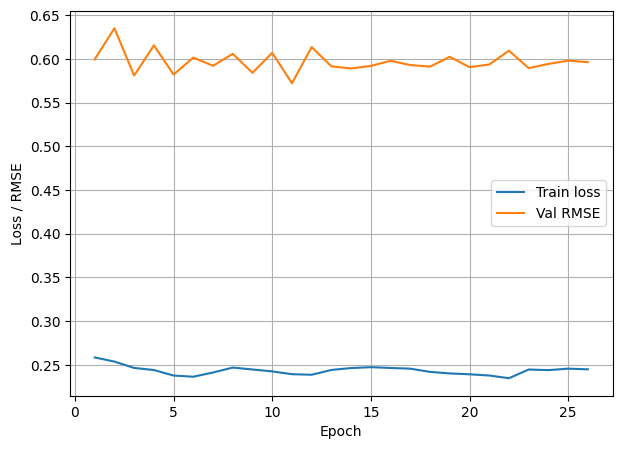

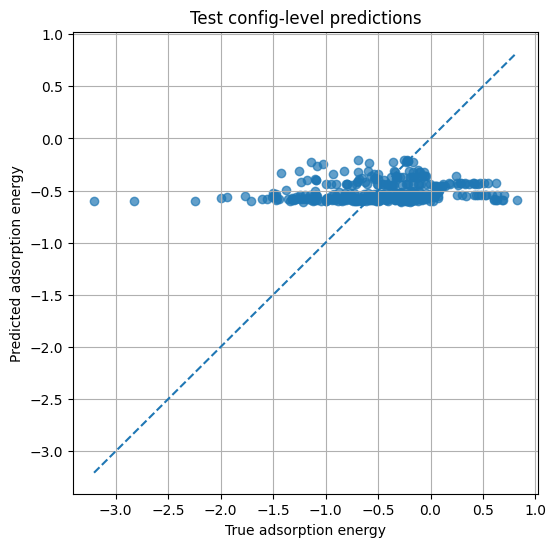

In [19]:
# 15) OPTIONAL PLOTS

import matplotlib.pyplot as plt

# Training curves
plt.figure(figsize=(7,5))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="Train loss")
plt.plot(hist_df["epoch"], hist_df["val_RMSE"], label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("Loss / RMSE")
plt.legend()
plt.grid(True)
plt.show()

# Predicted vs true on test config-level
plt.figure(figsize=(6,6))
plt.scatter(test_final["y_true"], test_final["y_pred"], alpha=0.7)
mn = min(test_final["y_true"].min(), test_final["y_pred"].min())
mx = max(test_final["y_true"].max(), test_final["y_pred"].max())
plt.plot([mn, mx], [mn, mx], '--')
plt.xlabel("True adsorption energy")
plt.ylabel("Predicted adsorption energy")
plt.title("Test config-level predictions")
plt.grid(True)
plt.show()

Uncertainty quantification - Ensemble/Bootstrapping and Interpretability - Atom Level something

Come back and check Early stopping Tab - MSE Loss and Mean predictions. possibly aggregation